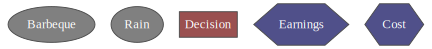

In [36]:
import pyAgrum as gum
import pyAgrum.lib.notebook as gnb

# Create an Influence Diagram with one-liners for variables
idg = gum.InfluenceDiagram()

# Add decision node
decision = idg.addDecisionNode(gum.LabelizedVariable('Decision', 'Decision', ['No Marquee', 'Marquee']))

# Add chance node for the binary outcome of the wheel spin (Win or No Win)
bbq = idg.addChanceNode(gum.LabelizedVariable('Barbeque', 'Barbeque', 2))
rain = idg.addChanceNode(gum.LabelizedVariable('Rain', 'Rain', 2))

# Add utility node for the payoff
earnings = idg.addUtilityNode(gum.LabelizedVariable('Earnings', 'Earnings', 1))
cost = idg.addUtilityNode(gum.LabelizedVariable('Cost', 'Cost', 1))

# Add links between nodes
idg.addArc(decision, bbq)
idg.addArc(decision, cost)
idg.addArc(bbq, earnings)
idg.addArc(rain, earnings)
idg.addArc(decision, earnings)
idg.addArc(rain, bbq)

# Let's look at our graph
gnb.showInfluenceDiagram(idg)

In [11]:
idg.cpt(bbq)[{'Decision': 0, 'Rain': 0}] = [0.0, 1.0]
idg.cpt(bbq)[{'Decision': 0, 'Rain': 1}] = [1.0, 0.0]
idg.cpt(bbq)[{'Decision': 1, 'Rain': 0}] = [0.0, 1.0]
idg.cpt(bbq)[{'Decision': 1, 'Rain': 1}] = [0.0, 1.0]
idg.cpt(rain).fillWith([0.95, 0.05])

idg.utility(earnings)[{'Decision': 0, 'Rain': 0, 'Barbeque': 0}] = 0
idg.utility(earnings)[{'Decision': 0, 'Rain': 0, 'Barbeque': 1}] = 100000
idg.utility(earnings)[{'Decision': 0, 'Rain': 1, 'Barbeque': 0}] = 0
idg.utility(earnings)[{'Decision': 0, 'Rain': 1, 'Barbeque': 1}] = -20000
idg.utility(earnings)[{'Decision': 1, 'Rain': 0, 'Barbeque': 0}] = 0
idg.utility(earnings)[{'Decision': 1, 'Rain': 0, 'Barbeque': 1}] = 100000
idg.utility(earnings)[{'Decision': 1, 'Rain': 1, 'Barbeque': 0}] = 0
idg.utility(earnings)[{'Decision': 1, 'Rain': 1, 'Barbeque': 1}] = 90000


idg.utility(cost)[{'Decision': 0}] = 0
idg.utility(cost)[{'Decision': 1}] = -10000

In [12]:
# PyAgrum can compute the expected total utility, summing all utilities:
ie = gum.ShaferShenoyLIMIDInference(idg)
ie.makeInference()
ie.posteriorUtility("Decision")

(pyAgrum.Potential<double>@0x600002164078) 
  Decision         |
No Marque|Marquee  |
---------|---------|
 95000.0000| 89500.0000|

In [13]:
# PyAgrum can also compute the optimal decision for us:
ie.optimalDecision("Decision")

(pyAgrum.Potential<double>@0x60000027dc20) 
  Decision         |
No Marque|Marquee  |
---------|---------|
 1.0000  | 0.0000  |

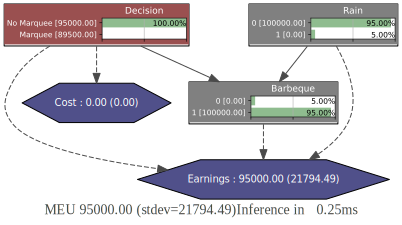

In [14]:
gnb.showInference(idg)

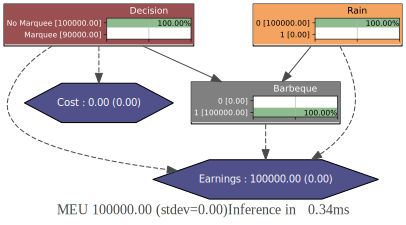

In [15]:
# We can use evidence, similar to how we would in a regular Bayesian network:
gnb.showInference(idg, evs={"Rain": 0})

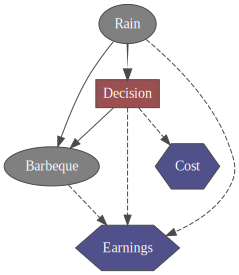

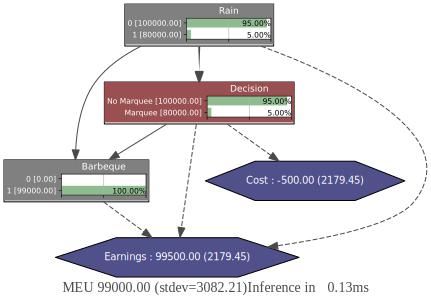

In [16]:
# We can simulate an "informed decision", i.e. a decision where we know the outcome of an event that hasn't happened yet
# Think of this as: "when we know whether it will rain, we make a decision on the marquee"
idg.addArc(rain, decision)
gnb.showInfluenceDiagram(idg)
gnb.showInference(idg)

In [18]:
# This can let us compute the *value of information*:

expected_utility_without_information_arc = 95000
expected_utility_with_information_arc = 99000

print("Value of knowing whether it rains when we decide: " + str(expected_utility_with_information_arc - expected_utility_without_information_arc))

Value of knowing whether it rains when we decide: 4000


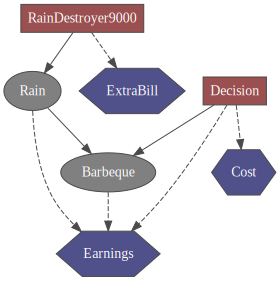

In [27]:
import pyAgrum as gum
import pyAgrum.lib.notebook as gnb

# Create an Influence Diagram with one-liners for variables
idg = gum.InfluenceDiagram()

# Add decision node
decision = idg.addDecisionNode(gum.LabelizedVariable('Decision', 'Decision', ['No Marquee', 'Marquee']))
rain_destroyer = idg.addDecisionNode(gum.LabelizedVariable('RainDestroyer9000', 'RainDestroyer9000', ['Don\'t activate', 'Activate']))

# Add chance node for the binary outcome of the wheel spin (Win or No Win)
bbq = idg.addChanceNode(gum.LabelizedVariable('Barbeque', 'Barbeque', 2))
rain = idg.addChanceNode(gum.LabelizedVariable('Rain', 'Rain', 2))

# Add utility node for the payoff
earnings = idg.addUtilityNode(gum.LabelizedVariable('Earnings', 'Earnings', 1))
cost = idg.addUtilityNode(gum.LabelizedVariable('Cost', 'Cost', 1))
destroyer_cost = idg.addUtilityNode(gum.LabelizedVariable('ExtraBill', 'ExtraBill', 1))

# Add links between nodes
idg.addArc(decision, bbq)
idg.addArc(decision, cost)
idg.addArc(bbq, earnings)
idg.addArc(rain, earnings)
idg.addArc(decision, earnings)
idg.addArc(rain, bbq)
idg.addArc(rain_destroyer, rain)
idg.addArc(rain_destroyer, destroyer_cost)

# Let's look at our graph
gnb.showInfluenceDiagram(idg)

In [34]:
idg.cpt(bbq)[{'Decision': 0, 'Rain': 0}] = [0.0, 1.0]
idg.cpt(bbq)[{'Decision': 0, 'Rain': 1}] = [1.0, 0.0]
idg.cpt(bbq)[{'Decision': 1, 'Rain': 0}] = [0.0, 1.0]
idg.cpt(bbq)[{'Decision': 1, 'Rain': 1}] = [0.0, 1.0]

idg.cpt(rain)[{'RainDestroyer9000': 0}] = [0.95, 0.05]
idg.cpt(rain)[{'RainDestroyer9000': 1}] = [1.0, 0.0]

idg.utility(earnings)[{'Decision': 0, 'Rain': 0, 'Barbeque': 0}] = 0
idg.utility(earnings)[{'Decision': 0, 'Rain': 0, 'Barbeque': 1}] = 100000
idg.utility(earnings)[{'Decision': 0, 'Rain': 1, 'Barbeque': 0}] = 0
idg.utility(earnings)[{'Decision': 0, 'Rain': 1, 'Barbeque': 1}] = -20000
idg.utility(earnings)[{'Decision': 1, 'Rain': 0, 'Barbeque': 0}] = 0
idg.utility(earnings)[{'Decision': 1, 'Rain': 0, 'Barbeque': 1}] = 100000
idg.utility(earnings)[{'Decision': 1, 'Rain': 1, 'Barbeque': 0}] = 0
idg.utility(earnings)[{'Decision': 1, 'Rain': 1, 'Barbeque': 1}] = 90000

idg.utility(cost)[{'Decision': 0}] = 0
idg.utility(cost)[{'Decision': 1}] = -10000

idg.utility(destroyer_cost)[{'RainDestroyer9000': 0}] = 0
idg.utility(destroyer_cost)[{'RainDestroyer9000': 1}] = -500

In [29]:
# THIS DOES NOT EXECUTE:
gnb.showInference(idg)

FatalError: [pyAgrum] Fatal error: This LIMID/Influence Diagram is not solvable.

In [30]:
# A limit of PyAgrum: If there are multiple decisions, we MUST choose in which order we make them.
idg.addArc(rain_destroyer, decision)

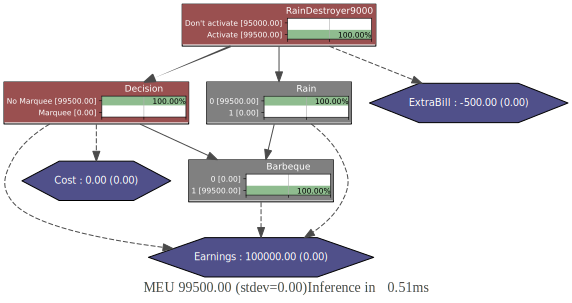

In [35]:
gnb.showInference(idg)